Position:
Long 25,000,000 EUR nominal of OAT 3.50% 25-Nov-2033
ISIN: FR001400L834

Objective:
Hedge the interest-rate risk of this French government bond using Bund Futures during Jan 2026 - Jun 2026.

Number of observations: 106
Start date: 2026-01-02
End date: 2026-06-30


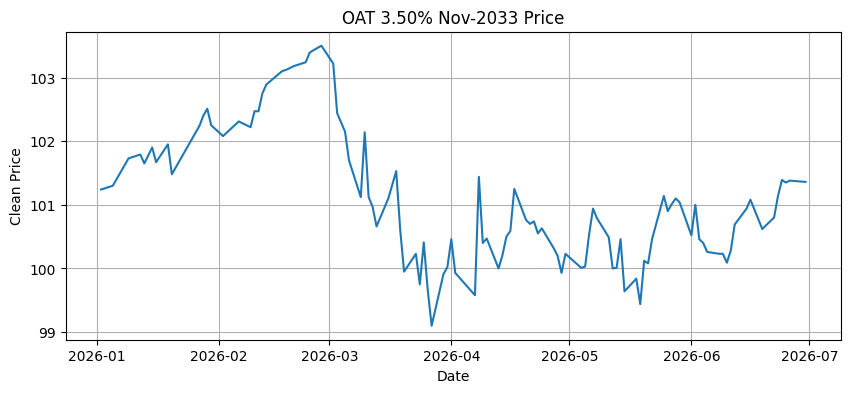

In [107]:
import pandas as pd
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.float_format", "{:,.2f}".format)

# File path
oat_price_file = "data/obligation.csv"

# Load OAT price data
oat = pd.read_csv(oat_price_file)

# Convert date column to datetime format
oat["date"] = pd.to_datetime(oat["date"])

# Keep only the 6-month simulation window
start_date = "2026-01-01"
end_date = "2026-06-30"

oat = oat[(oat["date"] >= start_date) & (oat["date"] <= end_date)].copy()

# Rename price column for clarity
oat = oat.rename(columns={"price": "oat_price"})

# Sort by date
oat = oat.sort_values("date").reset_index(drop=True)

# Quick check
print(f"Number of observations: {len(oat)}")
print(f"Start date: {oat['date'].min().date()}")
print(f"End date: {oat['date'].max().date()}")

plt.figure(figsize=(10, 4))
plt.plot(oat["date"], oat["oat_price"])
plt.title("OAT 3.50% Nov-2033 Price")
plt.xlabel("Date")
plt.ylabel("Clean Price")
plt.grid(True)
plt.show()

### Clean price to dirty price

For Jan-2026 to Jun-2026, accrued interest is computed using actual days since the last coupon.

In [108]:
annual_coupon = 100 * 0.035
previous_coupon_date = pd.Timestamp("2025-11-25")
next_coupon_date = pd.Timestamp("2026-11-25")

oat["next_coupon_date"] = next_coupon_date
oat["days_counter"] = (oat["date"] - previous_coupon_date).dt.days
oat["accrued_interest"] = annual_coupon * oat["days_counter"] / 365
oat["dirty_price"] = oat["oat_price"] + oat["accrued_interest"]

oat[["date", "oat_price", "next_coupon_date", "days_counter", "accrued_interest", "dirty_price"]].head()

,date,oat_price,next_coupon_date,days_counter,accrued_interest,dirty_price
0,2026-01-02,101.24,2026-11-25,38,0.36,101.60
1,2026-01-05,101.30,2026-11-25,41,0.39,101.69
2,2026-01-09,101.73,2026-11-25,45,0.43,102.16
3,2026-01-12,101.79,2026-11-25,48,0.46,102.25
4,2026-01-13,101.65,2026-11-25,49,0.47,102.12


### Yield from dirty price

For each date, we solve the yield that matches the observed dirty price.

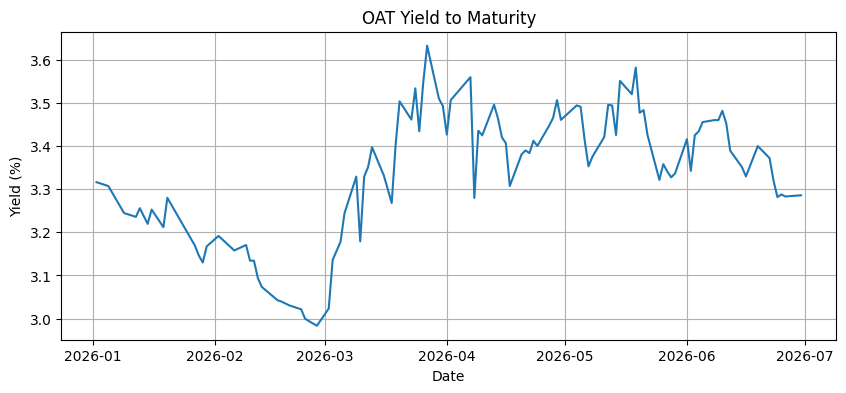

,date,dirty_price,yield_pct
0,2026-01-02,101.60,3.32
1,2026-01-05,101.69,3.31
2,2026-01-09,102.16,3.24
3,2026-01-12,102.25,3.24
4,2026-01-13,102.12,3.26


In [109]:
from scipy.optimize import brentq

# Future coupon dates and cashflows
coupon_dates = [pd.Timestamp(year, 11, 25) for year in range(2026, 2034)]
cashflows = [annual_coupon] * len(coupon_dates)
cashflows[-1] += 100  # final coupon + principal


def price_difference(yield_rate, settlement_date, market_price):
    model_price = sum(
        cashflow / (1 + yield_rate) ** ((payment_date - settlement_date).days / 365)
        for payment_date, cashflow in zip(coupon_dates, cashflows)
    )
    return model_price - market_price


oat["yield"] = oat.apply(
    lambda row: brentq(
        price_difference,
        -0.05,
        0.10,
        args=(row["date"], row["dirty_price"]),
    ),
    axis=1,
)

oat["yield_pct"] = oat["yield"] * 100

plt.figure(figsize=(10, 4))
plt.plot(oat["date"], oat["yield_pct"])
plt.title("OAT Yield to Maturity")
plt.xlabel("Date")
plt.ylabel("Yield (%)")
plt.grid(True)
plt.show()

oat[["date", "dirty_price", "yield_pct"]].head()

### Duration

Macaulay duration is the weighted average time of the bond cashflows, using present values as weights.

In [110]:
import numpy as np

durations = []

for _, row in oat.iterrows():
    settlement_date = row["date"]
    y = row["yield"]

    times = np.array([
        (payment_date - settlement_date).days / 365
        for payment_date in coupon_dates
    ])

    pvs = np.array([
        cashflow / (1 + y) ** t
        for cashflow, t in zip(cashflows, times)
    ])

    macaulay_duration = np.average(times, weights=pvs)
    modified_duration = macaulay_duration / (1 + y)

    durations.append([macaulay_duration, modified_duration])

oat[["macaulay_duration", "modified_duration"]] = durations

oat[["date", "yield_pct", "macaulay_duration", "modified_duration"]].head()

,date,yield_pct,macaulay_duration,modified_duration
0,2026-01-02,3.32,7.02,6.80
1,2026-01-05,3.31,7.01,6.79
2,2026-01-09,3.24,7.01,6.79
3,2026-01-12,3.24,7.00,6.78
4,2026-01-13,3.26,6.99,6.77


### DV01

DV01 is the approximate euro P&L impact of a 1 bp move in yield.

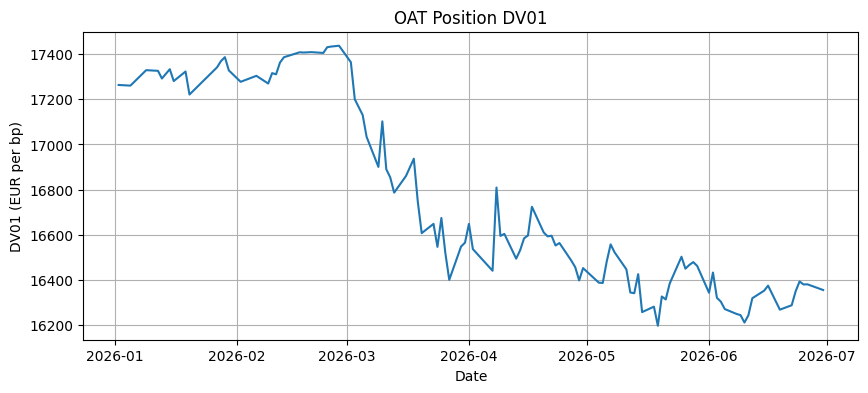

,date,dirty_price,modified_duration,market_value,oat_dv01_eur
0,2026-01-02,101.60,6.80,"25,401,095.89","17,263.60"
1,2026-01-05,101.69,6.79,"25,423,287.67","17,260.73"
2,2026-01-09,102.16,6.79,"25,540,376.71","17,329.16"
3,2026-01-12,102.25,6.78,"25,562,568.49","17,326.16"
4,2026-01-13,102.12,6.77,"25,529,965.75","17,292.14"


In [111]:
position_nominal = 25_000_000
one_basis_point = 0.0001

# Market value of the OAT position
oat["market_value"] = position_nominal * oat["dirty_price"] / 100

# Positive DV01: euro amount gained if yields fall by 1 bp
oat["oat_dv01_eur"] = oat["market_value"] * oat["modified_duration"] * one_basis_point

plt.figure(figsize=(10, 4))
plt.plot(oat["date"], oat["oat_dv01_eur"])
plt.title("OAT Position DV01")
plt.xlabel("Date")
plt.ylabel("DV01 (EUR per bp)")
plt.grid(True)
plt.show()

oat[["date", "dirty_price", "modified_duration", "market_value", "oat_dv01_eur"]].head()

### Unhedged bond P&L

The unhedged P&L is computed from the daily change in dirty price.

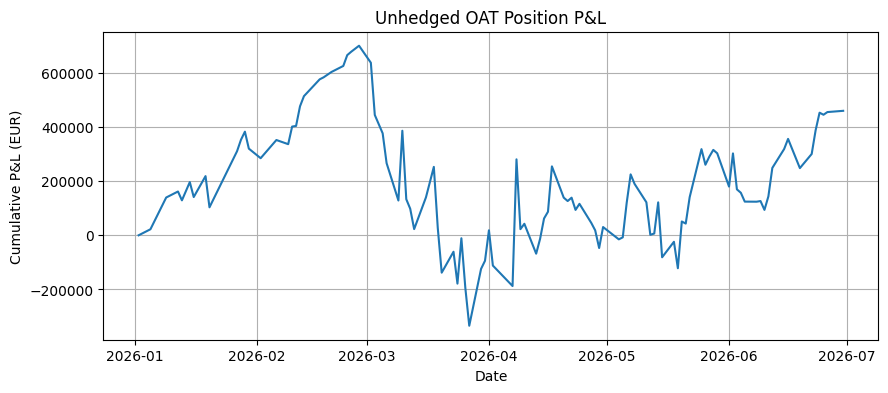

In [112]:
# Daily P&L of the cash bond position
oat["dirty_price_change"] = oat["dirty_price"].diff()
oat["bond_pnl"] = position_nominal * oat["dirty_price_change"] / 100
oat["bond_pnl"] = oat["bond_pnl"].fillna(0)

# Cumulative unhedged P&L
oat["cumulative_bond_pnl"] = oat["bond_pnl"].cumsum()

plt.figure(figsize=(10, 4))
plt.plot(oat["date"], oat["cumulative_bond_pnl"])
plt.title("Unhedged OAT Position P&L")
plt.xlabel("Date")
plt.ylabel("Cumulative P&L (EUR)")
plt.grid(True)
plt.show()


### Bund futures data

We use the Investing.com Bund futures series as a continuous front-contract proxy.

In [113]:
bund_file = "data/euro_bund_futures.csv"

bund = pd.read_csv(bund_file, decimal=",")
bund.columns = bund.columns.str.strip()

bund = bund.rename(columns={"Date": "date", "Dernier": "bund_future_price"})
bund["date"] = pd.to_datetime(bund["date"], dayfirst=True)

bund = bund[["date", "bund_future_price"]].sort_values("date").reset_index(drop=True)
bund = bund[(bund["date"] >= start_date) & (bund["date"] <= end_date)].copy()

# Keep only the OAT trading dates used in the simulation
oat = oat.drop(columns=["bund_future_price"], errors="ignore")
oat = oat.merge(bund, on="date", how="left")

print(f"Bund observations: {len(bund)}")
print(f"Missing Bund prices on OAT dates: {oat['bund_future_price'].isna().sum()}")

oat[["date", "oat_price", "bund_future_price"]].head()

Bund observations: 126
Missing Bund prices on OAT dates: 0


,date,oat_price,bund_future_price
0,2026-01-02,101.24,127.11
1,2026-01-05,101.30,127.40
2,2026-01-09,101.73,127.95
3,2026-01-12,101.79,128.17
4,2026-01-13,101.65,128.09


### Bund futures implied yield

As a simple proxy, we treat the Bund future as a 10-year notional German bond with a 6% coupon.

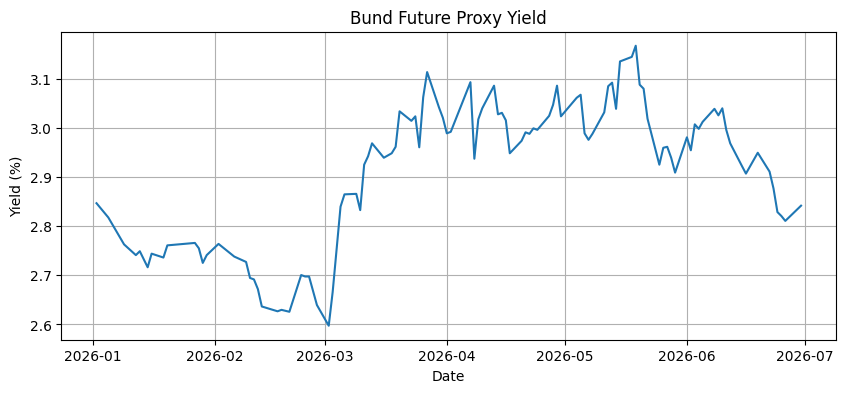

,date,bund_future_price,bund_yield_pct
0,2026-01-02,127.11,2.85
1,2026-01-05,127.40,2.82
2,2026-01-09,127.95,2.76
3,2026-01-12,128.17,2.74
4,2026-01-13,128.09,2.75


In [114]:
# Simplified Eurex notional bond proxy
bund_coupon_rate = 0.06
bund_annual_coupon = 100 * bund_coupon_rate
bund_times = np.arange(1, 11)
bund_cashflows = np.full(10, bund_annual_coupon)
bund_cashflows[-1] += 100


def bund_price_difference(yield_rate, market_price):
    model_price = np.sum(bund_cashflows / (1 + yield_rate) ** bund_times)
    return model_price - market_price


oat["bund_yield"] = oat["bund_future_price"].apply(
    lambda price: brentq(bund_price_difference, -0.05, 0.10, args=(price,))
)

oat["bund_yield_pct"] = oat["bund_yield"] * 100

plt.figure(figsize=(10, 4))
plt.plot(oat["date"], oat["bund_yield_pct"])
plt.title("Bund Future Proxy Yield")
plt.xlabel("Date")
plt.ylabel("Yield (%)")
plt.grid(True)
plt.show()

oat[["date", "bund_future_price", "bund_yield_pct"]].head()

### Bund futures duration

Duration is computed on the same notional bond proxy.

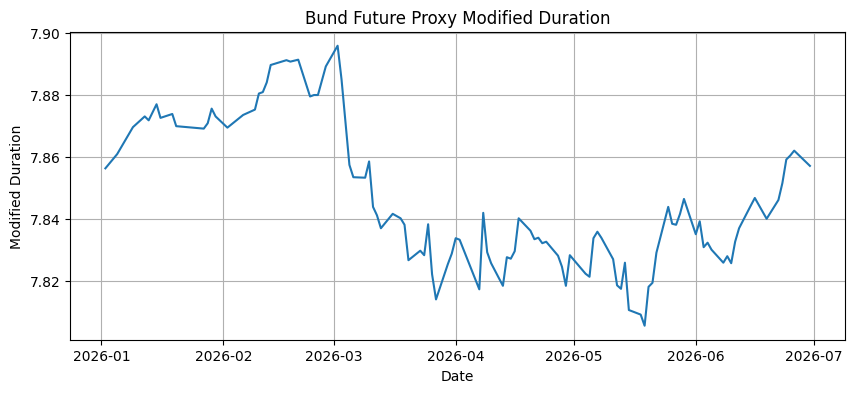

,date,bund_yield_pct,bund_macaulay_duration,bund_modified_duration
0,2026-01-02,2.85,8.08,7.86
1,2026-01-05,2.82,8.08,7.86
2,2026-01-09,2.76,8.09,7.87
3,2026-01-12,2.74,8.09,7.87
4,2026-01-13,2.75,8.09,7.87


In [115]:
bund_durations = []

for _, row in oat.iterrows():
    y = row["bund_yield"]
    pvs = bund_cashflows / (1 + y) ** bund_times

    bund_macaulay_duration = np.average(bund_times, weights=pvs)
    bund_modified_duration = bund_macaulay_duration / (1 + y)

    bund_durations.append([bund_macaulay_duration, bund_modified_duration])

oat[["bund_macaulay_duration", "bund_modified_duration"]] = bund_durations

plt.figure(figsize=(10, 4))
plt.plot(oat["date"], oat["bund_modified_duration"])
plt.title("Bund Future Proxy Modified Duration")
plt.xlabel("Date")
plt.ylabel("Modified Duration")
plt.grid(True)
plt.show()

oat[["date", "bund_yield_pct", "bund_macaulay_duration", "bund_modified_duration"]].head()

### Bund futures DV01

This is the approximate DV01 of one long Bund futures contract.

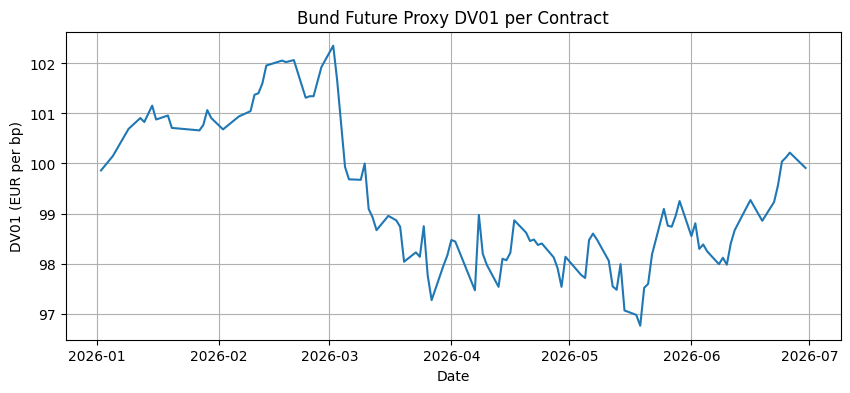

,date,bund_future_price,bund_modified_duration,bund_future_dv01_eur
0,2026-01-02,127.11,7.86,99.86
1,2026-01-05,127.40,7.86,100.15
2,2026-01-09,127.95,7.87,100.69
3,2026-01-12,128.17,7.87,100.91
4,2026-01-13,128.09,7.87,100.83


In [116]:
bund_future_notional = 100_000

oat["bund_contract_value_proxy"] = bund_future_notional * oat["bund_future_price"] / 100
oat["bund_future_dv01_eur"] = (
    oat["bund_contract_value_proxy"] * oat["bund_modified_duration"] * one_basis_point
)

plt.figure(figsize=(10, 4))
plt.plot(oat["date"], oat["bund_future_dv01_eur"])
plt.title("Bund Future Proxy DV01 per Contract")
plt.xlabel("Date")
plt.ylabel("DV01 (EUR per bp)")
plt.grid(True)
plt.show()

oat[["date", "bund_future_price", "bund_modified_duration", "bund_future_dv01_eur"]].head()

### Hedge ratio

The hedge ratio is the number of Bund futures contracts needed to offset the OAT DV01.

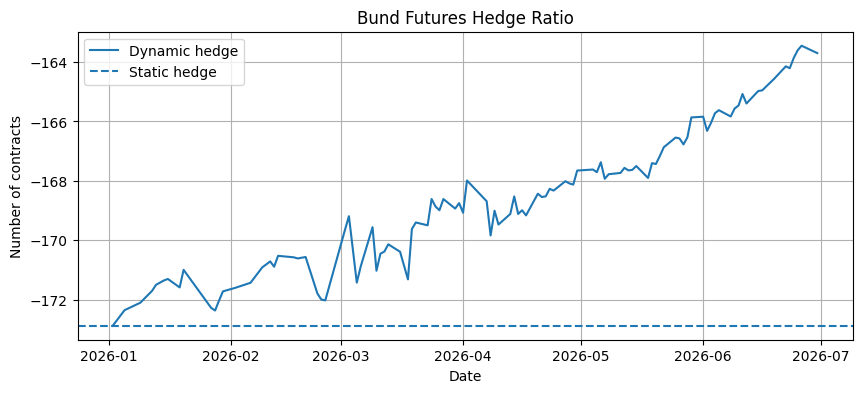

,date,oat_dv01_eur,bund_future_dv01_eur,static_contracts,dynamic_contracts
0,2026-01-02,"17,263.60",99.86,-172.88,-172.88
1,2026-01-05,"17,260.73",100.15,-172.88,-172.35
2,2026-01-09,"17,329.16",100.69,-172.88,-172.10
3,2026-01-12,"17,326.16",100.91,-172.88,-171.70
4,2026-01-13,"17,292.14",100.83,-172.88,-171.50


In [117]:
# Long OAT means long duration, so the hedge is short Bund futures
oat["dynamic_contracts"] = -oat["oat_dv01_eur"] / oat["bund_future_dv01_eur"]

# Static hedge: keep the first hedge ratio constant over the full period
static_contracts = oat["dynamic_contracts"].iloc[0]
oat["static_contracts"] = static_contracts

plt.figure(figsize=(10, 4))
plt.plot(oat["date"], oat["dynamic_contracts"], label="Dynamic hedge")
plt.axhline(static_contracts, linestyle="--", label="Static hedge")
plt.title("Bund Futures Hedge Ratio")
plt.xlabel("Date")
plt.ylabel("Number of contracts")
plt.grid(True)
plt.legend()
plt.show()

oat[["date", "oat_dv01_eur", "bund_future_dv01_eur", "static_contracts", "dynamic_contracts"]].head()

### Hedged P&L

Futures P&L uses yesterday's hedge position: contracts held from t-1 to t.

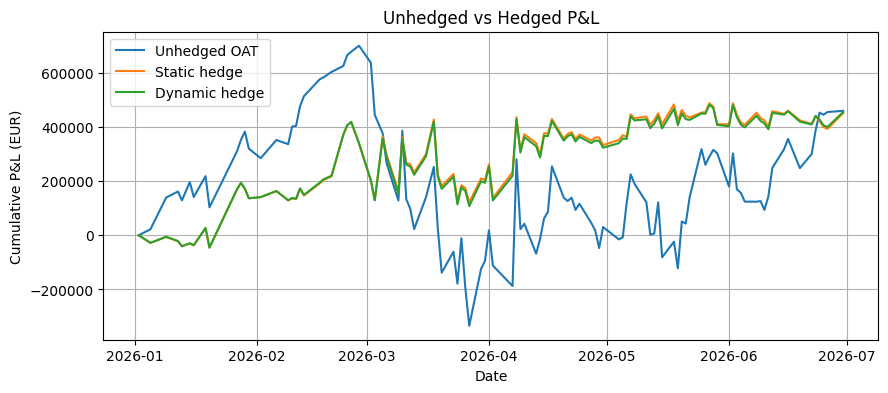

,date,bond_pnl,static_futures_pnl,dynamic_futures_pnl,static_hedged_pnl,dynamic_hedged_pnl
0,2026-01-02,0.00,0.00,0.00,0.00,0.00
1,2026-01-05,"22,191.78","-50,133.87","-50,133.87","-27,942.09","-27,942.09"
2,2026-01-09,"117,089.04","-95,081.48","-94,793.68","22,007.56","22,295.36"
3,2026-01-12,"22,191.78","-38,032.59","-37,862.22","-15,840.81","-15,670.44"
4,2026-01-13,"-32,602.74","13,830.03","13,736.01","-18,772.71","-18,866.73"


In [118]:
future_point_value = bund_future_notional / 100  # 1 price point = EUR 1,000

# Daily Bund Future price move
oat["bund_future_price_change"] = oat["bund_future_price"].diff()

# Futures P&L: contracts held yesterday x price move today x point value
oat["static_futures_pnl"] = (
    oat["static_contracts"].shift(1)
    * oat["bund_future_price_change"]
    * future_point_value
)

oat["dynamic_futures_pnl"] = (
    oat["dynamic_contracts"].shift(1)
    * oat["bund_future_price_change"]
    * future_point_value
)

oat[["static_futures_pnl", "dynamic_futures_pnl"]] = oat[
    ["static_futures_pnl", "dynamic_futures_pnl"]
].fillna(0)

# Total hedged P&L = cash bond P&L + futures hedge P&L
oat["static_hedged_pnl"] = oat["bond_pnl"] + oat["static_futures_pnl"]
oat["dynamic_hedged_pnl"] = oat["bond_pnl"] + oat["dynamic_futures_pnl"]

oat["cumulative_static_hedged_pnl"] = oat["static_hedged_pnl"].cumsum()
oat["cumulative_dynamic_hedged_pnl"] = oat["dynamic_hedged_pnl"].cumsum()

plt.figure(figsize=(10, 4))
plt.plot(oat["date"], oat["cumulative_bond_pnl"], label="Unhedged OAT")
plt.plot(oat["date"], oat["cumulative_static_hedged_pnl"], label="Static hedge")
plt.plot(oat["date"], oat["cumulative_dynamic_hedged_pnl"], label="Dynamic hedge")
plt.title("Unhedged vs Hedged P&L")
plt.xlabel("Date")
plt.ylabel("Cumulative P&L (EUR)")
plt.grid(True)
plt.legend()
plt.show()

oat[[
    "date",
    "bond_pnl",
    "static_futures_pnl",
    "dynamic_futures_pnl",
    "static_hedged_pnl",
    "dynamic_hedged_pnl",
]].head()

### Risk metrics

We compare max drawdown and daily P&L variance before and after the dynamic hedge.

In [119]:
initial_position_value = oat["market_value"].iloc[0]

# Max drawdown on cumulative P&L
unhedged_drawdown = oat["cumulative_bond_pnl"] - oat["cumulative_bond_pnl"].cummax()
dynamic_drawdown = oat["cumulative_dynamic_hedged_pnl"] - oat["cumulative_dynamic_hedged_pnl"].cummax()

# Daily P&L variance and volatility
unhedged_pnl_variance = oat["bond_pnl"].var()
dynamic_pnl_variance = oat["dynamic_hedged_pnl"].var()

unhedged_pnl_volatility = oat["bond_pnl"].std()
dynamic_pnl_volatility = oat["dynamic_hedged_pnl"].std()

risk_metrics = pd.DataFrame(
    {
        "strategy": ["Unhedged OAT", "Dynamic hedge"],
        "max_drawdown_eur": [unhedged_drawdown.min(), dynamic_drawdown.min()],
        "max_drawdown_pct": [
            unhedged_drawdown.min() / initial_position_value * 100,
            dynamic_drawdown.min() / initial_position_value * 100,
        ],
        "daily_pnl_variance": [unhedged_pnl_variance, dynamic_pnl_variance],
        "daily_pnl_volatility_eur": [unhedged_pnl_volatility, dynamic_pnl_volatility],
        "daily_pnl_volatility_pct": [
            unhedged_pnl_volatility / initial_position_value * 100,
            dynamic_pnl_volatility / initial_position_value * 100,
        ],
    }
)

risk_metrics

,strategy,max_drawdown_eur,max_drawdown_pct,daily_pnl_variance,daily_pnl_volatility_eur,daily_pnl_volatility_pct
0,Unhedged OAT,"-1,032,876.71",-4.07,"12,073,868,125.16","109,881.15",0.43
1,Dynamic hedge,"-311,334.95",-1.23,"4,742,977,505.91","68,869.28",0.27


### Residual spread risk

After hedging the Bund rate exposure, the remaining P&L is mainly driven by OAT-Bund spread moves, carry, basis and convexity.

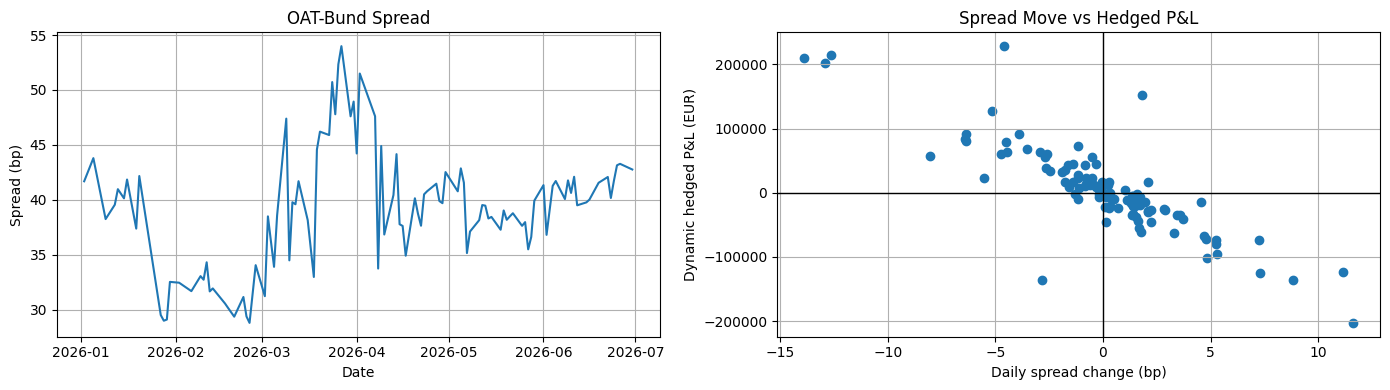

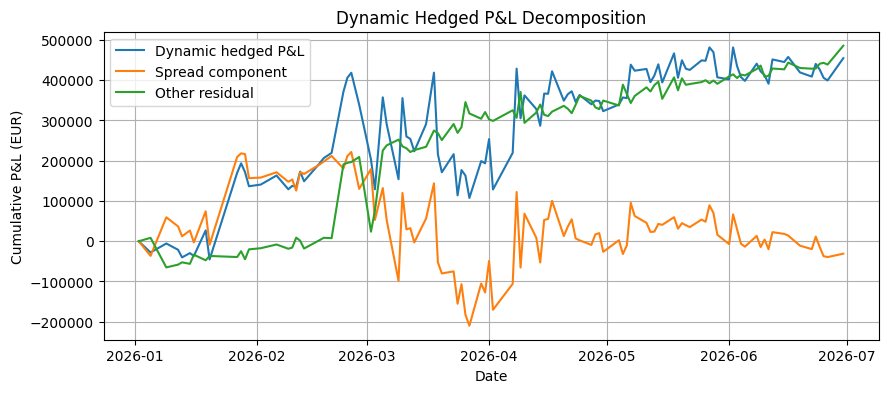

,metric,value
0,"corr(spread change, dynamic hedged P&L)",-0.85
1,final dynamic hedged P&L,"454,680.21"
2,final spread component,"-30,951.25"
3,final other residual,"485,631.46"


In [120]:
# Import cash Bund 10Y yield
bund_cash = pd.read_csv("data/bund.csv")
bund_cash["date"] = pd.to_datetime(bund_cash["date"])

oat = oat.drop(columns=["bund_10y_yield_pct", "bund_10y_yield"], errors="ignore")
oat = oat.merge(bund_cash, on="date", how="left")

# OAT-Bund spread in basis points
oat["oat_bund_spread_bp"] = (oat["yield"] - oat["bund_10y_yield"]) * 10_000
oat["spread_change_bp"] = oat["oat_bund_spread_bp"].diff().fillna(0)

# Approximate spread P&L: widening hurts a long OAT position
oat["spread_pnl_approx"] = -oat["oat_dv01_eur"].shift(1) * oat["spread_change_bp"]
oat["spread_pnl_approx"] = oat["spread_pnl_approx"].fillna(0)

# Residual not explained by spread proxy
oat["other_residual_pnl"] = oat["dynamic_hedged_pnl"] - oat["spread_pnl_approx"]

oat["cumulative_spread_pnl_approx"] = oat["spread_pnl_approx"].cumsum()
oat["cumulative_other_residual_pnl"] = oat["other_residual_pnl"].cumsum()

spread_pnl_correlation = oat[["spread_change_bp", "dynamic_hedged_pnl"]].corr().iloc[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(oat["date"], oat["oat_bund_spread_bp"])
axes[0].set_title("OAT-Bund Spread")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Spread (bp)")
axes[0].grid(True)

axes[1].scatter(oat["spread_change_bp"], oat["dynamic_hedged_pnl"])
axes[1].axhline(0, color="black", linewidth=1)
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("Spread Move vs Hedged P&L")
axes[1].set_xlabel("Daily spread change (bp)")
axes[1].set_ylabel("Dynamic hedged P&L (EUR)")
axes[1].grid(True)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(oat["date"], oat["cumulative_dynamic_hedged_pnl"], label="Dynamic hedged P&L")
plt.plot(oat["date"], oat["cumulative_spread_pnl_approx"], label="Spread component")
plt.plot(oat["date"], oat["cumulative_other_residual_pnl"], label="Other residual")
plt.title("Dynamic Hedged P&L Decomposition")
plt.xlabel("Date")
plt.ylabel("Cumulative P&L (EUR)")
plt.grid(True)
plt.legend()
plt.show()

pd.DataFrame(
    {
        "metric": [
            "corr(spread change, dynamic hedged P&L)",
            "final dynamic hedged P&L",
            "final spread component",
            "final other residual",
        ],
        "value": [
            spread_pnl_correlation,
            oat["cumulative_dynamic_hedged_pnl"].iloc[-1],
            oat["cumulative_spread_pnl_approx"].iloc[-1],
            oat["cumulative_other_residual_pnl"].iloc[-1],
        ],
    }
)

### Duration and convexity shock

For a large rate shock, duration alone is only a linear approximation. Adding convexity improves the price estimate.

In [121]:
# Choose a reference date for the shock
shock_row = oat.iloc[0]

shock_date = shock_row["date"]
current_yield = shock_row["yield"]
current_price = shock_row["dirty_price"]
modified_duration = shock_row["modified_duration"]

# +50 bp parallel shock on the OAT yield
yield_shock = 0.0050
shocked_yield = current_yield + yield_shock

# Future cashflow times from the shock date
times = np.array([
    (payment_date - shock_date).days / 365
    for payment_date in coupon_dates
])

cashflows_array = np.array(cashflows)

# Exact repricing after the shock
shocked_price_exact = np.sum(cashflows_array / (1 + shocked_yield) ** times)
exact_price_change = shocked_price_exact - current_price
exact_pnl = position_nominal * exact_price_change / 100

# Duration-only approximation
duration_price_change = -modified_duration * current_price * yield_shock
duration_pnl = position_nominal * duration_price_change / 100

# Convexity of the bond price with respect to yield
convexity = (
    np.sum(times * (times + 1) * cashflows_array / (1 + current_yield) ** (times + 2))
    / current_price
)

# Duration + convexity approximation
duration_convexity_price_change = current_price * (
    -modified_duration * yield_shock + 0.5 * convexity * yield_shock**2
)
duration_convexity_pnl = position_nominal * duration_convexity_price_change / 100

shock_results = pd.DataFrame(
    {
        "method": ["Exact repricing", "Duration only", "Duration + convexity"],
        "price_change": [
            exact_price_change,
            duration_price_change,
            duration_convexity_price_change,
        ],
        "pnl_eur": [exact_pnl, duration_pnl, duration_convexity_pnl],
        "error_vs_exact_eur": [
            0,
            duration_pnl - exact_pnl,
            duration_convexity_pnl - exact_pnl,
        ],
    }
)


print(f"Shock date: {shock_date.date()}")
print(f"Current yield: {current_yield * 100:.3f}%")
print(f"Shocked yield: {shocked_yield * 100:.3f}%")
print(f"Modified duration: {modified_duration:.2f}")
print(f"Convexity: {convexity:.2f}")

shock_results

Shock date: 2026-01-02
Current yield: 3.316%
Shocked yield: 3.816%
Modified duration: 6.80
Convexity: 56.25


,method,price_change,pnl_eur,error_vs_exact_eur
0,Exact repricing,-3.38,"-845,596.48",0.00
1,Duration only,-3.45,"-863,179.86","-17,583.38"
2,Duration + convexity,-3.38,"-845,320.54",275.94
